# Distribution Fitting

**What was wrong with Week 2.** Every variable was declared "not a good fit" by a Kolmogorov–Smirnov p-value, and the plots (linear x-axis, fitted curves invisible) could not show why. Three methodological problems:

1. **Invalid p-values.** The textbook KS p-value assumes the parameters are known. Here they were estimated from the same data, which makes the p-values wrong (too large in theory; the *Lilliefors* problem), and with n = 1,500 any test rejects tiny departures anyway.
2. **Ignoring truncation.** Revenue only exists above the top-1,500 cut-off. Fitting an un-truncated distribution to an upper-tail sample is misspecified.
3. **Testing instead of comparing.** "Is any candidate exactly true?" is always *no*. The useful question is "which candidate describes the data best, and how far off is it?"

**Approach.** Maximum-likelihood fits (left-truncated for revenue), model comparison by **AIC/BIC**, a **parametric-bootstrap KS** test that re-fits on every simulated sample (valid p-value), and **log-scale diagnostics** (density on log10 axis, Q-Q, log-log CCDF).

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))  # project root: import via the src package so src/statistics.py cannot shadow the stdlib module
from src import statistics as rs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4g}".format
pd.options.display.width = 140

df = rs.load_robust()
CLS = rs.CLASS_ORDER
PAL = rs.CLASS_COLORS
print(f"n = {len(df):,}  |  columns = {df.shape[1]}")

n = 1,500  |  columns = 20


In [2]:
from scipy import optimize
import powerlaw

x = df.revenue.values
XMIN = x.min()
LN10 = np.log(10)

def pdf_log10(dist, params, y, trunc=None):
    """Density of log10(X) implied by a fitted (optionally left-truncated) model."""
    xv = 10 ** y
    f = dist.pdf(xv, *params) * xv * LN10
    if trunc is not None:
        f = np.where(xv >= trunc, f / dist.sf(trunc * (1 - 1e-9), *params), 0.0)
    return f

def sf_trunc(dist, params, xv, trunc=None):
    s = dist.sf(xv, *params)
    return s / dist.sf(trunc * (1 - 1e-9), *params) if trunc is not None else s

def ppf_trunc(dist, params, u, trunc=None):
    if trunc is None:
        return dist.ppf(u, *params)
    f0 = dist.cdf(trunc * (1 - 1e-9), *params)
    return dist.ppf(f0 + u * (1 - f0), *params)

FAM = rs.POSITIVE_CANDIDATES
print(f"Revenue truncation point (minimum observed): ${XMIN:,.0f}")

Revenue truncation point (minimum observed): $20,674


## 1. Revenue: does accounting for truncation change the answer?

In [3]:
fit_naive = rs.fit_candidates(x)                         # what Week 2 implicitly assumed
fit_trunc = rs.fit_candidates(x, truncate_at=XMIN)       # likelihood conditional on X >= cut-off

show = lambda t: t[["distribution", "n_params", "loglik", "AIC", "dAIC", "BIC", "KS_D"]].round(3)
print("A. Un-truncated fit (misspecified for this sample)"); display(show(fit_naive))
print("B. Left-truncated fit at the observed minimum"); display(show(fit_trunc))

A. Un-truncated fit (misspecified for this sample)


,distribution,n_params,loglik,AIC,dAIC,BIC,KS_D
0,Inverse Gaussian,2,-2.083e+04,4.166e+04,0,4.167e+04,0.092
1,Lomax (Pareto II),2,-2.099e+04,4.198e+04,320.5,4.199e+04,0.135
2,Log-logistic,2,-2.1e+04,4.2e+04,334.6,4.201e+04,0.117
3,Lognormal,2,-2.102e+04,4.205e+04,385.6,4.206e+04,0.109
4,Weibull,2,-2.14e+04,4.28e+04,"1,141",4.281e+04,0.219
5,Gamma,2,-2.193e+04,4.386e+04,"2,202",4.388e+04,0.264


B. Left-truncated fit at the observed minimum


,distribution,n_params,loglik,AIC,dAIC,BIC,KS_D
0,Lognormal,2,-2.067e+04,4.134e+04,0,4.135e+04,0.02
1,Weibull,2,-2.067e+04,4.134e+04,1.201,4.135e+04,0.02
2,Log-logistic,2,-2.067e+04,4.135e+04,8.613,4.136e+04,0.024
3,Inverse Gaussian,2,-2.067e+04,4.135e+04,10.65,4.136e+04,0.02
4,Lomax (Pareto II),2,-2.067e+04,4.135e+04,16.53,4.136e+04,0.03
5,Gamma,2,-2.103e+04,4.207e+04,733.8,4.208e+04,0.401


The ranking changes, and so does the fit quality. Un-truncated, inverse-Gaussian ranks first but *no* family is adequate (KS D 0.09–0.26). Once the likelihood respects truncation, the **lognormal** is best (Weibull statistically indistinguishable, ΔAIC ≈ 1), the KS distance falls roughly five-fold to 0.02, and Gamma is decisively worst.

### 1.1 Valid goodness-of-fit: parametric-bootstrap KS

In [4]:
N_SIM = 500
d_ln, p_ln = rs.parametric_bootstrap_ks(x, stats.lognorm, truncate_at=XMIN, n_sim=N_SIM)
d_wb, p_wb = rs.parametric_bootstrap_ks(x, stats.weibull_min, truncate_at=XMIN, n_sim=N_SIM)
d_ln0, p_ln0 = rs.parametric_bootstrap_ks(x, stats.lognorm, truncate_at=None, n_sim=N_SIM)
boot_rev = pd.DataFrame([
    ["Lognormal, truncated", d_ln, p_ln], ["Weibull, truncated", d_wb, p_wb], ["Lognormal, un-truncated (Week 2 style)", d_ln0, p_ln0],
], columns=["model", "KS_D", f"bootstrap p ({N_SIM} re-fits)"])
boot_rev

,model,KS_D,bootstrap p (500 re-fits)
0,"Lognormal, truncated",0.02039,0.1178
1,"Weibull, truncated",0.02031,0.1557
2,"Lognormal, un-truncated (Week 2 style)",0.1091,0.001996


**Reading this.** A p-value well above 0.05 means the observed KS distance is typical of samples genuinely drawn from the fitted model — *no evidence of misfit*. The un-truncated lognormal is rejected decisively while the truncated lognormal is not: the Week 2 "no good fit" verdict for revenue was a **specification error (ignoring truncation)**, not a property of the data.

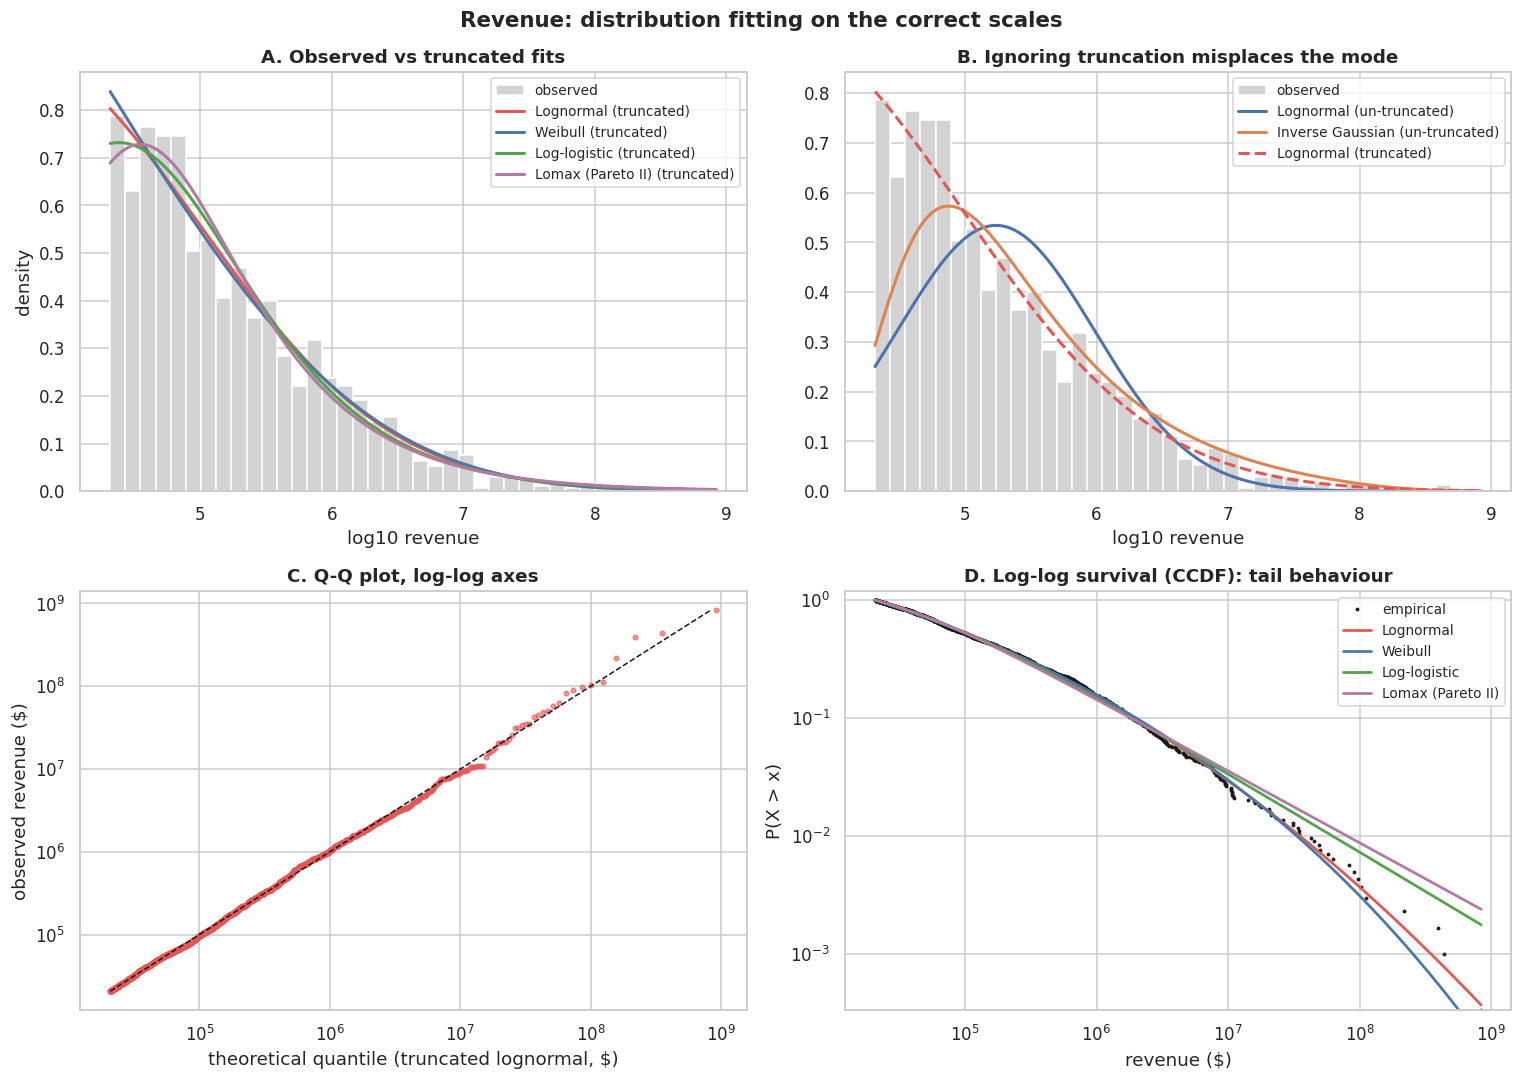

In [5]:
pars = {r_.distribution: r_.params for r_ in fit_trunc.itertuples()}
best_naive = fit_naive.iloc[0]
xs = np.sort(x); n = len(xs)
y_grid = np.linspace(np.log10(XMIN), np.log10(x.max()), 400)
palette = {"Lognormal": "#E45756", "Weibull": "#4C78A8", "Log-logistic": "#54A24B", "Lomax (Pareto II)": "#B279A2"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) density on log10 axis with truncated fits
ax = axes[0, 0]
ax.hist(df.log_revenue, bins=40, density=True, color="lightgrey", edgecolor="white", label="observed")
for nm, c in palette.items():
    ax.plot(y_grid, pdf_log10(FAM[nm], pars[nm], y_grid, XMIN), color=c, lw=2, label=f"{nm} (truncated)")
ax.set_xlabel("log10 revenue"); ax.set_ylabel("density"); ax.set_title("A. Observed vs truncated fits"); ax.legend(fontsize=9)

# (b) contrast: what Week 2 fitted
ax = axes[0, 1]
ax.hist(df.log_revenue, bins=40, density=True, color="lightgrey", edgecolor="white", label="observed")
for nm in ["Lognormal", best_naive.distribution]:
    p0 = fit_naive.set_index("distribution").loc[nm, "params"]
    ax.plot(y_grid, pdf_log10(FAM[nm], p0, y_grid), lw=2, label=f"{nm} (un-truncated)")
ax.plot(y_grid, pdf_log10(stats.lognorm, pars["Lognormal"], y_grid, XMIN), lw=2, color="#E45756", ls="--", label="Lognormal (truncated)")
ax.set_xlabel("log10 revenue"); ax.set_title("B. Ignoring truncation misplaces the mode"); ax.legend(fontsize=9)

# (c) Q-Q vs truncated lognormal
ax = axes[1, 0]
u = (np.arange(1, n + 1) - .5) / n
q = ppf_trunc(stats.lognorm, pars["Lognormal"], u, XMIN)
ax.loglog(q, xs, "o", ms=3, alpha=.6, color="#E45756")
lim = [xs.min(), xs.max()]; ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("theoretical quantile (truncated lognormal, $)"); ax.set_ylabel("observed revenue ($)"); ax.set_title("C. Q-Q plot, log-log axes")

# (d) CCDF
ax = axes[1, 1]
ccdf = 1 - (np.arange(1, n + 1) - .5) / n
ax.loglog(xs, ccdf, ".", ms=3, color="k", label="empirical")
grid = np.logspace(np.log10(XMIN), np.log10(x.max()), 300)
for nm, c in palette.items():
    ax.loglog(grid, sf_trunc(FAM[nm], pars[nm], grid, XMIN), color=c, lw=1.8, label=nm)
ax.set_ylim(1 / n / 2, 1.2); ax.set_xlabel("revenue ($)"); ax.set_ylabel("P(X > x)"); ax.set_title("D. Log-log survival (CCDF): tail behaviour"); ax.legend(fontsize=9)

fig.suptitle("Revenue: distribution fitting on the correct scales", fontweight="bold", fontsize=14)
fig.tight_layout(); rs.save_fig(fig, "r05_revenue_fit_diagnostics.png"); plt.show()

## 2. The extreme upper tail: power law?

Heavy-tailed commercial data are often modelled as power laws. The `powerlaw` package (Clauset–Shalizi–Newman) estimates the tail cut-off `xmin` by KS minimisation, fits the exponent, and compares alternatives by likelihood-ratio tests. A power law is **never** assumed — it must beat the alternatives.

In [6]:
fit_pl = powerlaw.Fit(x, verbose=False)
tail_n = int((x >= fit_pl.xmin).sum())
print(f"Estimated tail start xmin = ${fit_pl.xmin:,.0f}  ({tail_n} games, {tail_n / len(x):.1%} of sample)")
print(f"Power-law exponent alpha = {fit_pl.power_law.alpha:.2f} +/- {fit_pl.power_law.sigma:.2f}  (KS D = {fit_pl.power_law.D:.3f})")

comp = []
for a, b in [("power_law", "lognormal"), ("power_law", "exponential"), ("power_law", "truncated_power_law"), ("lognormal", "truncated_power_law")]:
    R, p = fit_pl.distribution_compare(a, b, normalized_ratio=True)
    comp.append([f"{a}  vs  {b}", R, p, a if R > 0 else b])
pl_tbl = pd.DataFrame(comp, columns=["comparison (tail only)", "normalized log-likelihood ratio R", "p", "favoured (sign of R)"])
pl_tbl

Estimated tail start xmin = $787,339  (282 games, 18.8% of sample)
Power-law exponent alpha = 1.76 +/- 0.05  (KS D = 0.032)


,comparison (tail only),normalized log-likelihood ratio R,p,favoured (sign of R)
0,power_law vs lognormal,-0.4912,0.6233,lognormal
1,power_law vs exponential,4.809,1.52e-06,power_law
2,power_law vs truncated_power_law,-1.28,0.2269,truncated_power_law
3,lognormal vs truncated_power_law,-1.056,0.2911,truncated_power_law


Interpretation rule: R > 0 favours the first model, R < 0 the second; the sign is only meaningful when p < 0.10. **Here** a power law clearly beats an exponential tail, but it is *not* distinguishable from a lognormal or a truncated power law (all p > 0.2). The data support "very heavy tail", not specifically "power law". A pure power law with α < 2 would even have an infinite theoretical mean — one more reason not to lean on the sample mean.

## 3. The other variables (no truncation issue)

`copiesSold`, `avgPlaytime`: continuous positive → the same family comparison. `price` (paid games): many ties at price points ($9.99, $14.99, …), so distributional families are only descriptive. `reviewScore`: bounded on (0, 100) and left-skewed → Beta / Normal / logit-Normal on the proportion scale.

In [7]:
rows, best_params = [], {}
targets = {"copiesSold": df.copiesSold.astype(float), "avgPlaytime": df.avgPlaytime.where(df.avgPlaytime > 0),
           "price (paid)": df.price.where(df.price > 0)}
for name, s in targets.items():
    s = s.dropna().values
    ft = rs.fit_candidates(s)
    best = ft.iloc[0]; second = ft.iloc[1]
    dist = FAM[best.distribution]
    if name != "price (paid)":
        D, pb = rs.parametric_bootstrap_ks(s, dist, n_sim=200)
    else:
        D, pb = best.KS_D, np.nan
    best_params[name] = (dist, best.params, s)
    rows.append([name, len(s), best.distribution, second.distribution, second.dAIC, D, pb])

# review score on proportion scale
sc = df.reviewScore_clean.dropna().values
y = np.clip((sc - .5) / 100, 1e-3, 1 - 1e-3)
a_, b_, _, _ = stats.beta.fit(y, floc=0, fscale=1)
mu_, sd_ = stats.norm.fit(y)
lg = np.log(y / (1 - y)); lmu, lsd = stats.norm.fit(lg)
ll = {"Beta": stats.beta.logpdf(y, a_, b_).sum(),
      "Normal": stats.norm.logpdf(y, mu_, sd_).sum(),
      "Logit-Normal": (stats.norm.logpdf(lg, lmu, lsd) - np.log(y * (1 - y))).sum()}
aic = {k: 2 * 2 - 2 * v for k, v in ll.items()}
rev_tbl = pd.DataFrame({"loglik": ll, "AIC": aic}); rev_tbl["dAIC"] = rev_tbl.AIC - rev_tbl.AIC.min()
best_rev = rev_tbl.dAIC.idxmin(); second_rev = rev_tbl.dAIC.nsmallest(2).index[1]
D_rev = stats.kstest(y, {"Beta": lambda v: stats.beta.cdf(v, a_, b_), "Normal": lambda v: stats.norm.cdf(v, mu_, sd_),
                         "Logit-Normal": lambda v: stats.norm.cdf(np.log(v / (1 - v)), lmu, lsd)}[best_rev]).statistic
rows.append(["reviewScore (scored)", len(sc), best_rev, second_rev, rev_tbl.loc[second_rev, "dAIC"], D_rev, np.nan])

rows.insert(0, ["revenue (truncated fit)", len(x), fit_trunc.iloc[0].distribution, fit_trunc.iloc[1].distribution,
                fit_trunc.iloc[1].dAIC, d_ln, p_ln])
summary = pd.DataFrame(rows, columns=["variable", "n", "best family (AIC)", "runner-up", "dAIC runner-up", "KS_D", "bootstrap p"])
rs.save_table(summary, "distribution_fits_robust.csv")
print("Review-score family comparison (proportion scale):"); display(rev_tbl.round(2))
print("Summary across variables:"); summary

Review-score family comparison (proportion scale):


,loglik,AIC,dAIC
Beta,"1,036","-2,067",0
Normal,775.6,"-1,547",520.2
Logit-Normal,"1,032","-2,061",6.5


Summary across variables:


,variable,n,best family (AIC),runner-up,dAIC runner-up,KS_D,bootstrap p
0,revenue (truncated fit),1500,Lognormal,Weibull,1.201,0.02039,0.1178
1,copiesSold,1500,Inverse Gaussian,Log-logistic,149.8,0.05726,0.004975
2,avgPlaytime,1499,Inverse Gaussian,Lognormal,3.114,0.03559,0.004975
3,price (paid),1415,Lognormal,Log-logistic,11.31,0.08736,NaN
4,reviewScore (scored),1401,Beta,Logit-Normal,6.495,0.04269,NaN


**Reading the summary.** Revenue is the only variable a standard family describes adequately (once truncation is respected). `copiesSold` and `avgPlaytime` are rejected by the parametric bootstrap (p ≈ 0.005, the minimum with 200 simulations) — they are heavy-tailed with lognormal-*like* bodies, but no two-parameter family is exact, and `copiesSold` is only indirectly truncated (selection was on revenue, not copies). For those variables use rank-based and resampling methods (notebook 06) rather than parametric ones. `reviewScore` is bounded and left-skewed: the **Beta** family beats the Normal by ΔAIC ≈ 520, which is why the Week 2 Normal fit looked wrong.

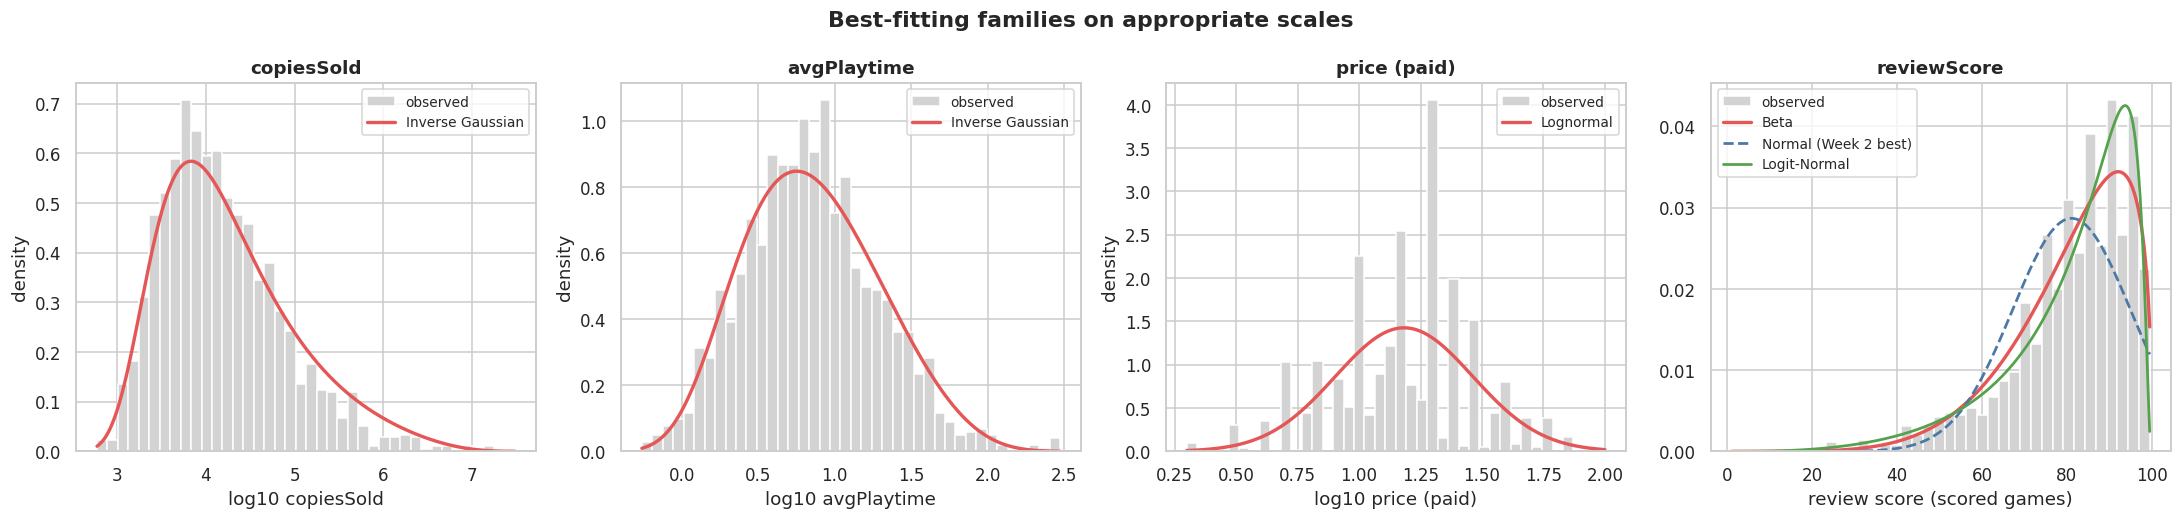

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
for ax, (name, (dist, params, s)) in zip(axes[:3], best_params.items()):
    ax.hist(np.log10(s), bins=40, density=True, color="lightgrey", edgecolor="white", label="observed")
    yg = np.linspace(np.log10(s.min()), np.log10(s.max()), 300)
    ax.plot(yg, pdf_log10(dist, params, yg), color="#E45756", lw=2.2, label=f"{summary.set_index('variable').loc[name, 'best family (AIC)']}")
    ax.set_xlabel(f"log10 {name}"); ax.set_ylabel("density"); ax.set_title(name); ax.legend(fontsize=9)
ax = axes[3]
ax.hist(y * 100, bins=35, density=True, color="lightgrey", edgecolor="white", label="observed")
g = np.linspace(.01, .995, 300)
ax.plot(g * 100, stats.beta.pdf(g, a_, b_) / 100, lw=2.2, color="#E45756", label="Beta")
ax.plot(g * 100, stats.norm.pdf(g, mu_, sd_) / 100, lw=1.8, color="#4C78A8", ls="--", label="Normal (Week 2 best)")
ax.plot(g * 100, stats.norm.pdf(np.log(g / (1 - g)), lmu, lsd) / (g * (1 - g)) / 100, lw=1.8, color="#54A24B", label="Logit-Normal")
ax.set_xlabel("review score (scored games)"); ax.set_title("reviewScore"); ax.legend(fontsize=9)
fig.suptitle("Best-fitting families on appropriate scales", fontweight="bold")
fig.tight_layout(); rs.save_fig(fig, "r05_other_variables_fits.png"); plt.show()